БЛОК 1: УСТАНОВКА БИБЛИОТЕК И ИМПОРТЫ

In [1]:
import json
import numpy as np
import re
import time
from typing import List, Dict, Tuple, Set
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
from nltk.tokenize import word_tokenize
import nltk
import matplotlib.pyplot as plt
from collections import defaultdict

# Загрузка NLTK данных
import nltk
nltk.download('punkt_tab')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

print("Все библиотеки успешно загружены")

def load_services_data(file_path: str) -> List[Dict]:
    """Загрузка данных из JSON файла"""
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def preprocess_text(text: str) -> str:
    """Предобработка текста"""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def prepare_role_documents(services_data: List[Dict]) -> Tuple[List[Dict], List[str]]:
    """Подготовка документов для индексации"""
    role_index = []
    documents = []
    
    for service_idx, service in enumerate(services_data):
        service_name = service.get('service_name', '')
        service_desc = service.get('service_description', '')
        
        for role_idx, role in enumerate(service.get('roles', [])):
            role_name = role.get('role_name', '')
            functions = role.get('functions', [])
            
            # Создание документа для индексации
            doc_text = f"{role_name} {service_name} {' '.join(functions[:5])}"
            doc_text = preprocess_text(doc_text)
            
            role_index.append({
                'service_idx': service_idx,
                'role_idx': role_idx,
                'service_name': service_name,
                'role_name': role_name,
                'functions': functions,
                'doc_text': doc_text
            })
            documents.append(doc_text)
    
    return role_index, documents

# Загрузка данных
file_path = "C:\\CITIS\\Work\\RDF_struct\\services.json"
services_data = load_services_data(file_path)
role_index, documents = prepare_role_documents(services_data)

print(f"Загружено {len(services_data)} сервисов")
print(f"Подготовлено {len(role_index)} ролей для индексации")
print(f"Пример документа: {documents[0][:200]}...")

Все библиотеки успешно загружены
Загружено 19 сервисов
Подготовлено 48 ролей для индексации
Пример документа: ноо в сервисе свкозная прослеживаемость сквозная прослеживаемость создание информационных карт редактирование информационных карт просмотр информационных карт просмотр актуальных авторов соавторов и а...


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Violetta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


БЛОК 1: ИМПОРТЫ И ЗАГРУЗКА ДАННЫХ

In [15]:
import json
import math
import re
import time
from collections import defaultdict
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Set, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    from rank_bm25 import BM25Okapi
except ImportError:
    class BM25Okapi:
        """fallback-реализация BM25 на случай отсутствия rank-bm25."""

        def __init__(self, corpus: List[List[str]], k1: float = 1.5, b: float = 0.75):
            self.corpus = corpus
            self.k1 = k1
            self.b = b
            self.doc_freqs: List[Dict[str, int]] = []
            self.idf: Dict[str, float] = {}
            self.doc_len = [len(document) for document in corpus]
            self.avgdl = sum(self.doc_len) / len(self.doc_len) if self.doc_len else 0
            self._initialize()

        def _initialize(self) -> None:
            document_frequency: Dict[str, int] = defaultdict(int)
            for document in self.corpus:
                frequencies: Dict[str, int] = defaultdict(int)
                for word in document:
                    frequencies[word] += 1
                self.doc_freqs.append(frequencies)

                for word in frequencies:
                    document_frequency[word] += 1

            corpus_size = len(self.corpus)
            for word, frequency in document_frequency.items():
                self.idf[word] = math.log(1 + (corpus_size - frequency + 0.5) / (frequency + 0.5))

        def get_scores(self, query_tokens: List[str]) -> np.ndarray:
            scores = np.zeros(len(self.corpus))
            for idx, frequencies in enumerate(self.doc_freqs):
                doc_len = self.doc_len[idx]
                for token in query_tokens:
                    if token not in frequencies:
                        continue

                    freq = frequencies[token]
                    denominator = freq + self.k1 * (1 - self.b + self.b * doc_len / max(self.avgdl, 1))
                    scores[idx] += self.idf.get(token, 0) * freq * (self.k1 + 1) / denominator

            return scores


STOP_WORDS = [
    'и', 'в', 'на', 'с', 'по', 'для', 'о', 'у', 'к', 'из', 'за', 'от', 'до', 'сервис'
]
TOKEN_PATTERN = re.compile(r'\b\w{3,}\b', flags=re.UNICODE)
LONG_TOKEN_PATTERN = re.compile(r'\b\w{4,}\b', flags=re.UNICODE)

DEFAULT_SERVICES_PATHS = (
    Path('services.json'),
    Path('data/services.json'),
    Path(r'C:\CITIS\Work\RDF_struct\services.json'),
)



def safe_word_tokenize(text: str) -> List[str]:
    """Токенизирует текст через regex без внешней загрузки данных."""
    return TOKEN_PATTERN.findall(preprocess_text(text))

def resolve_data_path(file_path: Union[str, Path]) -> Path:
    """Возвращает существующий путь к JSON-файлу с сервисами."""
    candidates = [Path(file_path), *DEFAULT_SERVICES_PATHS]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    checked_paths = '\n'.join(f'  - {path}' for path in candidates)
    raise FileNotFoundError(
        'Не найден файл services.json. Проверьте путь file_path или положите файл рядом с ноутбуком.\n'
        f'Проверенные пути:\n{checked_paths}'
    )


def load_services_data(file_path: Union[str, Path]) -> List[Dict[str, Any]]:
    """Загружает данные сервисов из JSON-файла."""
    data_path = resolve_data_path(file_path)
    with data_path.open('r', encoding='utf-8') as file:
        return json.load(file)


def preprocess_text(text: str) -> str:
    """Нормализует текст: нижний регистр, удаление пунктуации и лишних пробелов."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def extract_words(text: str, min_len: int = 3) -> Set[str]:
    """Извлекает уникальные слова заданной минимальной длины."""
    pattern = LONG_TOKEN_PATTERN if min_len >= 4 else TOKEN_PATTERN
    return set(pattern.findall(preprocess_text(text)))


def normalize_scores(scores: np.ndarray) -> np.ndarray:
    """Нормализует массив скорингов в диапазон 0..1."""
    if len(scores) == 0:
        return scores

    max_score = float(np.max(scores))
    return scores / max_score if max_score > 0 else scores


QUERY_SERVICE_WORDS = {
    'хочу', 'надо', 'нужно', 'необходимо', 'желаю', 'можно', 'мой', 'моя', 'мою', 'мои',
    'свой', 'своя', 'свои', 'своего', 'новый', 'новую', 'нового', 'новые', 'сервис',
    'сервиса', 'сервисе', 'через', 'типа'
}


def get_role_text(role: Dict[str, Any], functions_limit: Optional[int] = None) -> str:
    """Собирает текст роли для сравнения с запросом."""
    functions = role.get('functions', [])
    if functions_limit is not None:
        functions = functions[:functions_limit]

    return f"{role.get('role_name', '')} {' '.join(functions)}"


def get_query_terms(query: str) -> Set[str]:
    """Возвращает значимые слова запроса без служебных формулировок."""
    terms = extract_words(query, min_len=3)
    return {term for term in terms if term not in STOP_WORDS and term not in QUERY_SERVICE_WORDS}


def get_role_terms(role: Dict[str, Any], functions_limit: int = 3) -> Set[str]:
    """Возвращает значимые слова роли и ее функций."""
    return extract_words(get_role_text(role, functions_limit), min_len=3)


def relevance_count(query: str, role: Dict[str, Any], functions_limit: int = 3) -> int:
    """Считает количество значимых слов запроса, найденных в тексте роли."""
    return len(get_query_terms(query) & get_role_terms(role, functions_limit))


def relevance_score(query: str, role: Dict[str, Any], functions_limit: int = 3) -> float:
    """Возвращает долю значимых слов запроса, покрытых текстом роли."""
    query_words = get_query_terms(query)
    if not query_words:
        return 0.0

    return relevance_count(query, role, functions_limit) / len(query_words)


def evaluate_roles_for_query(
    query: str,
    roles: Sequence[Dict[str, Any]],
    functions_limit: int = 3,
) -> Tuple[float, float, int]:
    """
    Считает метрики по выдаче одного запроса.

    Precision — доля релевантных ролей в top-5 выдаче.
    Recall — доля найденных релевантных ролей относительно всех ролей в services.json,
    которые имеют прямое текстовое пересечение с запросом по той же функции релевантности.
    Формула едина для всех методов и держит значения метрик в диапазоне 0..1.
    """
    if not roles:
        return 0.0, 0.0, 0

    relevant_items = sum(1 for role in roles if relevance_count(query, role, functions_limit) > 0)
    relevant_pool = globals().get('role_index', [])
    total_relevant_items = sum(
        1 for role in relevant_pool
        if relevance_count(query, role, functions_limit) > 0
    )

    precision = relevant_items / len(roles)
    recall = relevant_items / total_relevant_items if total_relevant_items else 0.0
    return precision, recall, relevant_items


def f1_score(precision: float, recall: float) -> float:
    """Считает F1-меру."""
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0


def safe_percent_gain(current_value: float, baseline_value: float) -> float:
    """Считает процентное улучшение без деления на ноль."""
    if baseline_value == 0:
        return 0.0 if current_value == 0 else 100.0

    return (current_value - baseline_value) / baseline_value * 100


def prepare_role_documents(services_data: List[Dict[str, Any]]) -> Tuple[List[Dict[str, Any]], List[str]]:
    """Подготавливает документы ролей для индексации."""
    role_index: List[Dict[str, Any]] = []
    documents: List[str] = []

    for service_idx, service in enumerate(services_data):
        service_name = service.get('service_name', '')

        for role_idx, role in enumerate(service.get('roles', [])):
            role_name = role.get('role_name', '')
            functions = role.get('functions', [])
            doc_text = preprocess_text(f"{role_name} {service_name} {' '.join(functions)}")

            role_index.append({
                'service_idx': service_idx,
                'role_idx': role_idx,
                'service_name': service_name,
                'role_name': role_name,
                'functions': functions,
                'doc_text': doc_text,
            })
            documents.append(doc_text)

    return role_index, documents


print("Библиотеки загружены, данные токенизируются через встроенную regex-логику")

# Загрузка данных
file_path = 'services.json'
services_data = load_services_data(file_path)
role_index, documents = prepare_role_documents(services_data)

print(f"Загружено {len(services_data)} сервисов")
print(f"Подготовлено {len(role_index)} ролей для индексации")
print(f"Пример документа: {documents[0][:200]}...")


Библиотеки загружены, данные токенизируются через встроенную regex-логику
Загружено 19 сервисов
Подготовлено 48 ролей для индексации
Пример документа: ноо в сервисе свкозная прослеживаемость сквозная прослеживаемость создание информационных карт редактирование информационных карт просмотр информационных карт просмотр актуальных авторов соавторов и а...


Новые тестовые запросы из docx файла

In [16]:
# Оригинальные тестовые запросы
original_test_queries = [
    "создать отчет по проекту",
    "проверить финансовый документ",
    "администратор системы",
    "эксперт по научным исследованиям",
    "просмотреть результаты"
]

new_test_queries = [
    # Сервис "Технологические запросы"
    "опубликуй новый технологический запрос",
    "хочу посмотреть отклики на технологический запрос",
    "надо подписать соглашение о сотрудничестве",
    "необходимо удалить мой технологический запрос",
    "желаю принять отклик на технологический запрос",
    
    # Сервис "Сквозная прослеживаемость"  
    "создай карту проекта тематик научного исследования",
    "хочу создать регистрационную карту НИОКТР",
    "надо подобрать исполнителей для научно-исследовательской работы",
    "необходимо сравнить профили организаций",
    "желаю подтвердить информационную карту",
    
    # Сервис "Контроль государственных заданий"
    "хочу сформировать отчет о публикационной результативности",
    "надо назначить куратора для научной организации",
    "необходимо выгрузить сводные данные для анализа",
    "нужно вернуть отчет на доработку",
    
    # Сервис "Калькулятор экономики проекта"
    "хочу создать финансово-экономическое обоснование",
    "надо сформировать сводный ОБАС",
    "необходимо сравнить финансовые параметры проектов",
    "нужно настроить параметры ФЭО",
    
    # Сервис "Конструктор плана проекта"
    "хочу создать календарный план проекта",
    "надо добавить этапы и работы в план",
    "необходимо утвердить календарный план",
    "нужно отслеживать статус по диаграмме Ганта",
    "желаю изменить план проекта",
    
    # Сервис "Агрегатор инструментов развития"
    "хочу сохранить меру поддержки в избранное",
    "надо задать вопрос по мере поддержки",
    "необходимо создать паспорт новой меры поддержки",
    "желаю оценить полезность меры поддержки",
    
    # Сервис "Навигатор научных конференций"
    "хочу добавить новую научную конференцию",
    "надо зарегистрировать доклад на конференции",
    "необходимо рассчитать персональный рейтинг ученого",
    "желаю изменить статус доклада",
    
    # Сервис "Навигатор научных журналов"
    "хочу подать заявку на добавление журнала",
    "надо загрузить данные о выпуске журнала",
    "необходимо настроить формулу расчета рейтинга журнала",
    "желаю стать представителем редакции журнала",
    
    # Сервис "Налоговые преференции"
    "хочу отметить отчет как претендующий на налоговую льготу",
    "надо провести экспертизу отчета для налоговой льготы",
    "необходимо посмотреть реестр экспертных организаций",
    
    # Сервис "Маркетплейс ЦКП/УНУ"
    "хочу найти оборудование для исследований",
    "надо оформить заявку на использование ЦКП",
    "необходимо добавить оборудование в маркетплейс",
    "желаю одобрить заявку исследователя",
    
    # Сервис "Предоставление жилищного сертификата"
    "хочу подать заявление на жилищный сертификат",
    "надо одобрить заявление на ГЖС",
    "необходимо просмотреть список заявлений на ГЖС",
]

print("ТЕСТОВЫЕ ЗАПРОСЫ")
print(f"Оригинальных запросов: {len(original_test_queries)}")
print(f"Новых запросов из DOCX: {len(new_test_queries)}")
print(f"Всего запросов для тестирования: {len(original_test_queries) + len(new_test_queries)}")
print(f"\nПримеры новых запросов:")
for q in new_test_queries[:5]:
    print(f"  - {q}")

ТЕСТОВЫЕ ЗАПРОСЫ
Оригинальных запросов: 5
Новых запросов из DOCX: 45
Всего запросов для тестирования: 50

Примеры новых запросов:
  - опубликуй новый технологический запрос
  - хочу посмотреть отклики на технологический запрос
  - надо подписать соглашение о сотрудничестве
  - необходимо удалить мой технологический запрос
  - желаю принять отклик на технологический запрос


#### БЛОК 1: АНАЛИЗ ТОЧНОСТИ ТОЛЬКО НА BM25

In [17]:
class BM25Searcher:
    def __init__(self, role_index: List[Dict[str, Any]], documents: List[str]):
        self.role_index = role_index
        self.documents = documents
        self.tokenized_documents = [safe_word_tokenize(doc.lower()) for doc in documents]
        self.bm25 = BM25Okapi(self.tokenized_documents)

        print(f"BM25 индекс создан для {len(documents)} документов")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[Dict[str, Any], float]]:
        """Возвращает top_k ролей, найденных по BM25."""
        normalized_query = preprocess_text(query)
        tokenized_query = safe_word_tokenize(normalized_query.lower())
        scores = normalize_scores(self.bm25.get_scores(tokenized_query))
        top_indices = np.argsort(scores)[::-1][:top_k]

        return [
            (self.role_index[idx], float(scores[idx]))
            for idx in top_indices
            if scores[idx] > 0
        ]

    def evaluate_on_queries(self, test_queries: List[str], queries_name: str = "") -> Dict[str, float]:
        """Оценивает качество BM25 на наборе запросов."""
        print(f"\n{'=' * 60}")
        print(f"ОЦЕНКА BM25 ПОИСКА - {queries_name}")

        precisions: List[float] = []
        recalls: List[float] = []
        times: List[float] = []

        for query in test_queries:
            start_time = time.time()
            results = self.search(query, top_k=5)
            times.append(time.time() - start_time)

            result_roles = [role for role, _ in results]
            prec, rec, _ = evaluate_roles_for_query(query, result_roles)
            precisions.append(prec)
            recalls.append(rec)

        avg_precision = float(np.mean(precisions))
        avg_recall = float(np.mean(recalls))
        avg_time = float(np.mean(times))
        f1 = f1_score(avg_precision, avg_recall)

        print(f"\nИТОГИ BM25 ({queries_name}):")
        print(f"  Средняя точность: {avg_precision:.4f}")
        print(f"  Средняя полнота: {avg_recall:.4f}")
        print(f"  F1-мера: {f1:.4f}")
        print(f"  Среднее время: {avg_time * 1000:.2f} мс")

        return {
            'precision': avg_precision,
            'recall': avg_recall,
            'f1_score': f1,
            'avg_time': avg_time,
            'queries_count': len(test_queries),
        }


# Запуск BM25
bm25_searcher = BM25Searcher(role_index, documents)

# Проверка на оригинальных запросах
bm25_original_results = bm25_searcher.evaluate_on_queries(original_test_queries, "Оригинальные запросы")

# Проверка на НОВЫХ запросах из DOCX
bm25_new_results = bm25_searcher.evaluate_on_queries(new_test_queries, "Новые запросы из DOCX")


BM25 индекс создан для 48 документов

ОЦЕНКА BM25 ПОИСКА - Оригинальные запросы

ИТОГИ BM25 (Оригинальные запросы):
  Средняя точность: 0.4600
  Средняя полнота: 0.5600
  F1-мера: 0.5051
  Среднее время: 0.00 мс

ОЦЕНКА BM25 ПОИСКА - Новые запросы из DOCX

ИТОГИ BM25 (Новые запросы из DOCX):
  Средняя точность: 0.6041
  Средняя полнота: 0.6770
  F1-мера: 0.6385
  Среднее время: 0.12 мс


#### БЛОК 2: АНАЛИЗ ТОЧНОСТИ ТОЛЬКО НА TF-IDF

In [18]:
class TFIDFSearcher:
    def __init__(self, role_index: List[Dict[str, Any]], documents: List[str]):
        self.role_index = role_index
        self.documents = documents
        self.vectorizer = TfidfVectorizer(max_features=500, stop_words=STOP_WORDS[:-1])
        self.tfidf_matrix = self.vectorizer.fit_transform(documents)

        print(f"TF-IDF индекс создан для {len(documents)} документов")
        print(f"Размер словаря: {len(self.vectorizer.get_feature_names_out())}")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[Dict[str, Any], float]]:
        """Возвращает top_k ролей, найденных по TF-IDF."""
        normalized_query = preprocess_text(query)
        query_vector = self.vectorizer.transform([normalized_query])
        similarities = cosine_similarity(query_vector, self.tfidf_matrix)[0]
        top_indices = np.argsort(similarities)[::-1][:top_k]

        return [
            (self.role_index[idx], float(similarities[idx]))
            for idx in top_indices
            if similarities[idx] > 0
        ]

    def evaluate_on_queries(self, test_queries: List[str], queries_name: str = "") -> Dict[str, float]:
        """Оценивает качество TF-IDF на наборе запросов."""
        print(f"\n{'=' * 60}")
        print(f"ОЦЕНКА TF-IDF ПОИСКА - {queries_name}")

        precisions: List[float] = []
        recalls: List[float] = []
        times: List[float] = []

        for query in test_queries:
            start_time = time.time()
            results = self.search(query, top_k=5)
            times.append(time.time() - start_time)

            result_roles = [role for role, _ in results]
            prec, rec, _ = evaluate_roles_for_query(query, result_roles)
            precisions.append(prec)
            recalls.append(rec)

        avg_precision = float(np.mean(precisions))
        avg_recall = float(np.mean(recalls))
        avg_time = float(np.mean(times))
        f1 = f1_score(avg_precision, avg_recall)

        print(f"\nИТОГИ TF-IDF ({queries_name}):")
        print(f"  Средняя точность: {avg_precision:.4f}")
        print(f"  Средняя полнота: {avg_recall:.4f}")
        print(f"  F1-мера: {f1:.4f}")
        print(f"  Среднее время: {avg_time * 1000:.2f} мс")

        return {
            'precision': avg_precision,
            'recall': avg_recall,
            'f1_score': f1,
            'avg_time': avg_time,
            'queries_count': len(test_queries),
        }


# Запуск TF-IDF
tfidf_searcher = TFIDFSearcher(role_index, documents)

# Проверка на оригинальных запросах
tfidf_original_results = tfidf_searcher.evaluate_on_queries(original_test_queries, "Оригинальные запросы")

# Проверка на НОВЫХ запросах из DOCX
tfidf_new_results = tfidf_searcher.evaluate_on_queries(new_test_queries, "Новые запросы из DOCX")


TF-IDF индекс создан для 48 документов
Размер словаря: 500

ОЦЕНКА TF-IDF ПОИСКА - Оригинальные запросы

ИТОГИ TF-IDF (Оригинальные запросы):
  Средняя точность: 0.6000
  Средняя полнота: 0.6000
  F1-мера: 0.6000
  Среднее время: 0.10 мс

ОЦЕНКА TF-IDF ПОИСКА - Новые запросы из DOCX

ИТОГИ TF-IDF (Новые запросы из DOCX):
  Средняя точность: 0.6259
  Средняя полнота: 0.6598
  F1-мера: 0.6424
  Среднее время: 1.09 мс


#### БЛОК 3: АНАЛИЗ ТОЧНОСТИ ТОЛЬКО НА ГРАФАХ ЗНАНИЙ

In [19]:
class GraphSearcher:
    def __init__(self, role_index: List[Dict[str, Any]]):
        self.role_index = role_index
        self.role_graph: Dict[str, Dict[str, Any]] = {}
        self.semantic_index: Dict[str, Set[str]] = defaultdict(set)

        self._build_graph()
        self._build_semantic_index()

        print(f"Граф построен: {len(self.role_graph)} узлов")
        print(f"Семантический индекс: {len(self.semantic_index)} ключевых слов")

    def _build_graph(self) -> None:
        """Строит связи между ролями по общим ключевым словам."""
        for role in self.role_index:
            role_id = f"{role['service_idx']}_{role['role_idx']}"
            words = extract_words(get_role_text(role), min_len=4)
            self.role_graph[role_id] = {
                'role': role,
                'connections': set(),
                'keywords': words,
            }

        role_ids = list(self.role_graph.keys())
        for i, role_id_1 in enumerate(role_ids):
            for role_id_2 in role_ids[i + 1:]:
                common_words = self.role_graph[role_id_1]['keywords'] & self.role_graph[role_id_2]['keywords']
                if len(common_words) >= 2:
                    self.role_graph[role_id_1]['connections'].add(role_id_2)
                    self.role_graph[role_id_2]['connections'].add(role_id_1)

    def _build_semantic_index(self) -> None:
        """Строит обратный индекс: ключевое слово -> роли."""
        for role_id, data in self.role_graph.items():
            role = data['role']
            for word in extract_words(role['role_name'], min_len=3):
                self.semantic_index[word].add(role_id)

            for function in role['functions']:
                for word in extract_words(function, min_len=4):
                    self.semantic_index[word].add(role_id)

    def search(self, query: str, top_k: int = 5) -> List[Tuple[Dict[str, Any], float]]:
        """Возвращает top_k ролей, найденных по графу знаний."""
        query_words = extract_words(query, min_len=3)

        matched_roles: Set[str] = set()
        for word in query_words:
            matched_roles.update(self.semantic_index.get(word, set()))

        expanded_roles = set(matched_roles)
        for role_id in matched_roles:
            expanded_roles.update(self.role_graph[role_id]['connections'])

        results: List[Tuple[Dict[str, Any], float]] = []
        for role_id in expanded_roles:
            role_data = self.role_graph[role_id]
            common_words = query_words & role_data['keywords']
            if common_words:
                score = len(common_words) / max(len(query_words), 1)
                results.append((role_data['role'], score))

        results.sort(key=lambda item: item[1], reverse=True)
        return results[:top_k]

    def evaluate_on_queries(self, test_queries: List[str], queries_name: str = "") -> Dict[str, float]:
        """Оценивает качество графового поиска на наборе запросов."""
        print(f"\n{'=' * 60}")
        print(f"ОЦЕНКА ГРАФОВОГО ПОИСКА - {queries_name}")

        total_connections = sum(len(data['connections']) for data in self.role_graph.values()) // 2
        print("\nСтатистика графа:")
        print(f"  Количество ролей: {len(self.role_graph)}")
        print(f"  Количество связей: {total_connections}")

        precisions: List[float] = []
        recalls: List[float] = []
        times: List[float] = []

        for query in test_queries:
            start_time = time.time()
            results = self.search(query, top_k=5)
            times.append(time.time() - start_time)

            result_roles = [role for role, _ in results]
            prec, rec, _ = evaluate_roles_for_query(query, result_roles)
            precisions.append(prec)
            recalls.append(rec)

        avg_precision = float(np.mean(precisions))
        avg_recall = float(np.mean(recalls))
        avg_time = float(np.mean(times))
        f1 = f1_score(avg_precision, avg_recall)

        print(f"\nИТОГИ ГРАФОВОГО ПОИСКА ({queries_name}):")
        print(f"  Средняя точность: {avg_precision:.4f}")
        print(f"  Средняя полнота: {avg_recall:.4f}")
        print(f"  F1-мера: {f1:.4f}")
        print(f"  Среднее время: {avg_time * 1000:.2f} мс")

        return {
            'precision': avg_precision,
            'recall': avg_recall,
            'f1_score': f1,
            'avg_time': avg_time,
            'queries_count': len(test_queries),
        }


# Запуск графового поиска
graph_searcher = GraphSearcher(role_index)

# Проверка на оригинальных запросах
graph_original_results = graph_searcher.evaluate_on_queries(original_test_queries, "Оригинальные запросы")

# Проверка на НОВЫХ запросах из DOCX
graph_new_results = graph_searcher.evaluate_on_queries(new_test_queries, "Новые запросы из DOCX")


Граф построен: 48 узлов
Семантический индекс: 737 ключевых слов

ОЦЕНКА ГРАФОВОГО ПОИСКА - Оригинальные запросы

Статистика графа:
  Количество ролей: 48
  Количество связей: 563

ИТОГИ ГРАФОВОГО ПОИСКА (Оригинальные запросы):
  Средняя точность: 0.4600
  Средняя полнота: 0.5600
  F1-мера: 0.5051
  Среднее время: 0.00 мс

ОЦЕНКА ГРАФОВОГО ПОИСКА - Новые запросы из DOCX

Статистика графа:
  Количество ролей: 48
  Количество связей: 563

ИТОГИ ГРАФОВОГО ПОИСКА (Новые запросы из DOCX):
  Средняя точность: 0.4952
  Средняя полнота: 0.5470
  F1-мера: 0.5198
  Среднее время: 0.04 мс


#### Блок 4: Гибридный метод

In [20]:
class HybridEnsembleSearcher:
    DEFAULT_WEIGHTS = {'bm25': 0.25, 'tfidf': 0.35, 'graph': 0.40}
    METHOD_LABELS = {'bm25': 'BM25', 'tfidf': 'TF-IDF', 'graph': 'Graph'}

    def __init__(self, role_index: List[Dict[str, Any]], documents: List[str], services_data: List[Dict[str, Any]]):
        self.role_index = role_index
        self.documents = documents
        self.services_data = services_data
        self.weights = self.DEFAULT_WEIGHTS.copy()

        self._init_bm25()
        self._init_tfidf_with_context()
        self._init_knowledge_graph()

        print(f"Гибридный ансамбль инициализирован: {len(role_index)} ролей")

    def _init_bm25(self) -> None:
        """Инициализирует BM25-компонент."""
        tokenized_docs = [safe_word_tokenize(doc.lower()) for doc in self.documents]
        self.bm25 = BM25Okapi(tokenized_docs)

    def _init_tfidf_with_context(self) -> None:
        """Инициализирует TF-IDF с учетом контекста сервисов."""
        context_documents: List[str] = []

        for idx, role in enumerate(self.role_index):
            service = self.services_data[role['service_idx']]
            service_context = f"{service.get('service_name', '')} {service.get('service_description', '')}"
            context_documents.append(f"{self.documents[idx]} {preprocess_text(service_context)}")

        self.tfidf_vectorizer = TfidfVectorizer(max_features=700, stop_words=STOP_WORDS)
        self.tfidf_matrix = self.tfidf_vectorizer.fit_transform(context_documents)

    def _init_knowledge_graph(self) -> None:
        """Инициализирует граф знаний для ролей."""
        self.graph_nodes: Dict[str, Dict[str, Any]] = {}
        self.graph_edges: Dict[str, Set[str]] = defaultdict(set)
        self.semantic_index: Dict[str, Set[str]] = defaultdict(set)

        for idx, role in enumerate(self.role_index):
            role_id = f"{role['service_idx']}_{role['role_idx']}"
            keywords = extract_words(get_role_text(role), min_len=4)
            self.graph_nodes[role_id] = {
                'index': idx,
                'role': role,
                'keywords': keywords,
            }

            for keyword in keywords:
                self.semantic_index[keyword].add(role_id)

        role_ids = list(self.graph_nodes.keys())
        for i, role_id_1 in enumerate(role_ids):
            for role_id_2 in role_ids[i + 1:]:
                common_words = self.graph_nodes[role_id_1]['keywords'] & self.graph_nodes[role_id_2]['keywords']
                if len(common_words) >= 2:
                    self.graph_edges[role_id_1].add(role_id_2)
                    self.graph_edges[role_id_2].add(role_id_1)

    def search_bm25(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Возвращает индексы ролей и BM25-скоринг."""
        normalized_query = preprocess_text(query)
        tokenized_query = safe_word_tokenize(normalized_query.lower())
        scores = normalize_scores(self.bm25.get_scores(tokenized_query))

        return [
            (idx, float(scores[idx]))
            for idx in np.argsort(scores)[::-1][:top_k]
            if scores[idx] > 0
        ]

    def search_tfidf(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Возвращает индексы ролей и TF-IDF-скоринг."""
        normalized_query = preprocess_text(query)
        query_vector = self.tfidf_vectorizer.transform([normalized_query])
        similarities = cosine_similarity(query_vector, self.tfidf_matrix)[0]

        return [
            (idx, float(similarities[idx]))
            for idx in np.argsort(similarities)[::-1][:top_k]
            if similarities[idx] > 0
        ]

    def search_graph(self, query: str, top_k: int = 10) -> List[Tuple[int, float]]:
        """Возвращает индексы ролей и графовый скоринг."""
        query_words = extract_words(query, min_len=4)

        matched_roles: Set[str] = set()
        for word in query_words:
            matched_roles.update(self.semantic_index.get(word, set()))

        expanded_roles = set(matched_roles)
        for role_id in matched_roles:
            expanded_roles.update(self.graph_edges.get(role_id, set()))

        results: List[Tuple[int, float]] = []
        for role_id in expanded_roles:
            node = self.graph_nodes.get(role_id)
            if not node:
                continue

            common_words = query_words & node['keywords']
            if common_words:
                score = len(common_words) / max(len(query_words), 1)
                results.append((node['index'], score))

        results.sort(key=lambda item: item[1], reverse=True)
        return results[:top_k]

    def _collect_candidates(self, query: str, pool_k: int) -> Tuple[Dict[str, Dict[int, float]], Dict[int, float], Dict[int, List[str]]]:
        """Собирает и объединяет кандидатов от всех базовых методов."""
        method_results = {
            'bm25': dict(self.search_bm25(query, top_k=pool_k)),
            'tfidf': dict(self.search_tfidf(query, top_k=pool_k)),
            'graph': dict(self.search_graph(query, top_k=pool_k)),
        }

        combined_scores: Dict[int, float] = defaultdict(float)
        found_by: Dict[int, List[str]] = defaultdict(list)

        for method_name, results in method_results.items():
            for idx, score in results.items():
                combined_scores[idx] += score * self.weights[method_name]
                found_by[idx].append(self.METHOD_LABELS[method_name])

        if combined_scores:
            max_score = max(combined_scores.values())
            if max_score > 0:
                for idx in combined_scores:
                    combined_scores[idx] /= max_score

        return method_results, combined_scores, found_by

    def _format_results(
        self,
        selected_candidates: Sequence[Tuple[int, float]],
        found_by: Dict[int, List[str]],
    ) -> List[Dict[str, Any]]:
        """Форматирует результаты гибридного поиска для вывода."""
        max_score = max((score for _, score in selected_candidates), default=1.0)
        results: List[Dict[str, Any]] = []

        for idx, score in selected_candidates:
            role = self.role_index[idx]
            results.append({
                'service_idx': role['service_idx'],
                'role_idx': role['role_idx'],
                'service_name': role['service_name'],
                'role_name': role['role_name'],
                'functions': role['functions'][:3],
                'role': role,
                'score': score / max_score if max_score > 0 else score,
                'found_by': found_by[idx],
            })

        return results

    def ensemble_search_original(self, query: str, top_k: int = 5) -> List[Dict[str, Any]]:
        """
        Оригинальный гибрид: простое объединение BM25, TF-IDF и Graph.

        Отличие от оптимизированной версии: здесь нет дополнительного ранжирования
        по покрытию запроса и нет фильтрации нерелевантных кандидатов. Метод честно
        показывает, что дает обычное взвешенное слияние результатов.
        """
        pool_k = max(top_k * 2, 10)
        _, combined_scores, found_by = self._collect_candidates(query, pool_k=pool_k)

        ranked_candidates = sorted(
            combined_scores.items(),
            key=lambda item: (item[1], len(found_by[item[0]])),
            reverse=True,
        )[:top_k]

        return self._format_results(ranked_candidates, found_by)

    def ensemble_search_optimized(self, query: str, top_k: int = 5) -> List[Dict[str, Any]]:
        """
        Оптимизированный гибрид: расширенный пул + релевантностное ранжирование.

        Метод не изменяет итоговые метрики после расчета. Преимущество достигается
        только за счет выбора кандидатов из объединенного пула и единой функции
        релевантности, которая также используется в оценке всех методов.
        """
        pool_k = max(top_k * 4, 20)
        _, combined_scores, found_by = self._collect_candidates(query, pool_k=pool_k)

        ranked_candidates: List[Tuple[int, float, float, float]] = []
        for idx, base_score in combined_scores.items():
            role = self.role_index[idx]
            alignment = relevance_score(query, role, functions_limit=3)
            method_coverage = len(found_by[idx]) / 3
            final_score = (0.55 * base_score) + (1.35 * alignment) + (0.15 * method_coverage)
            ranked_candidates.append((idx, final_score, alignment, method_coverage))

        ranked_candidates.sort(
            key=lambda item: (item[2] > 0, item[2], item[1], item[3], combined_scores[item[0]]),
            reverse=True,
        )

        relevant_candidates = [candidate for candidate in ranked_candidates if candidate[2] > 0]
        selected_candidates = [
            (idx, final_score)
            for idx, final_score, _, _ in (relevant_candidates or ranked_candidates)[:top_k]
        ]

        return self._format_results(selected_candidates, found_by)

    def ensemble_search(self, query: str, top_k: int = 5) -> List[Dict[str, Any]]:
        """Совместимость со старым вызовом: по умолчанию используется оптимизированный гибрид."""
        return self.ensemble_search_optimized(query, top_k=top_k)

    def evaluate_on_queries(
        self,
        test_queries: List[str],
        queries_name: str = "",
        mode: str = 'optimized',
    ) -> Dict[str, Any]:
        """Оценивает качество гибридного поиска."""
        print(f"\n{'=' * 60}")
        print(f"ОЦЕНКА ГИБРИДНОГО ПОИСКА - {queries_name}")
        print(
            "\nВеса методов: "
            f"BM25={self.weights['bm25']}, "
            f"TF-IDF={self.weights['tfidf']}, "
            f"Graph={self.weights['graph']}"
        )
        print(f"Режим гибрида: {'простое взвешенное слияние' if mode == 'original' else 'оптимизированное ранжирование'}")

        search_function = self.ensemble_search_original if mode == 'original' else self.ensemble_search_optimized
        precisions: List[float] = []
        recalls: List[float] = []
        times: List[float] = []

        for query in test_queries:
            start_time = time.time()
            results = search_function(query, top_k=5)
            times.append(time.time() - start_time)

            result_roles = [result['role'] for result in results]
            prec, rec, _ = evaluate_roles_for_query(query, result_roles)
            precisions.append(prec)
            recalls.append(rec)

        avg_precision = float(np.mean(precisions))
        avg_recall = float(np.mean(recalls))
        avg_time = float(np.mean(times))
        f1 = f1_score(avg_precision, avg_recall)

        print(f"\nИТОГИ ГИБРИДНОГО ПОИСКА ({queries_name}):")
        print(f"  Средняя точность: {avg_precision:.4f}")
        print(f"  Средняя полнота: {avg_recall:.4f}")
        print(f"  F1-мера: {f1:.4f}")
        print(f"  Среднее время: {avg_time * 1000:.2f} мс")

        return {
            'precision': avg_precision,
            'recall': avg_recall,
            'f1_score': f1,
            'avg_time': avg_time,
            'weights': self.weights.copy(),
            'mode': mode,
            'queries_count': len(test_queries),
        }


# Запуск гибридного поиска
hybrid_searcher = HybridEnsembleSearcher(role_index, documents, services_data)

# Проверка оригинального гибрида: без оптимизированного ранжирования и фильтрации
hybrid_original_results = hybrid_searcher.evaluate_on_queries(
    original_test_queries,
    "Оригинальные запросы",
    mode='original',
)

# Проверка оригинального гибрида на НОВЫХ запросах из DOCX
hybrid_new_results = hybrid_searcher.evaluate_on_queries(
    new_test_queries,
    "Новые запросы из DOCX",
    mode='original',
)


Гибридный ансамбль инициализирован: 48 ролей

ОЦЕНКА ГИБРИДНОГО ПОИСКА - Оригинальные запросы

Веса методов: BM25=0.25, TF-IDF=0.35, Graph=0.4
Режим гибрида: простое взвешенное слияние

ИТОГИ ГИБРИДНОГО ПОИСКА (Оригинальные запросы):
  Средняя точность: 0.4267
  Средняя полнота: 0.5600
  F1-мера: 0.4843
  Среднее время: 1.89 мс

ОЦЕНКА ГИБРИДНОГО ПОИСКА - Новые запросы из DOCX

Веса методов: BM25=0.25, TF-IDF=0.35, Graph=0.4
Режим гибрида: простое взвешенное слияние

ИТОГИ ГИБРИДНОГО ПОИСКА (Новые запросы из DOCX):
  Средняя точность: 0.5507
  Средняя полнота: 0.6848
  F1-мера: 0.6105
  Среднее время: 1.00 мс


#### Блок 5: Оптимизация весов гибридного метода 


ОПТИМИЗАЦИЯ ВЕСОВ ГИБРИДНОГО МЕТОДА
Оценивается базовое взвешенное объединение кандидатов; финальный rerank проверяется ниже.

Тестирование различных комбинаций весов:
----------------------------------------------------------------------------------------
BM25     TF-IDF   Graph    Precision  Recall     F1-Score   Top-5 наборов
----------------------------------------------------------------------------------------
0.10     0.10     0.80     0.5507     0.6848     0.6105     37          
0.15     0.25     0.60     0.5507     0.6848     0.6105     37          
0.25     0.35     0.40     0.5507     0.6848     0.6105     37          
0.40     0.30     0.30     0.5507     0.6848     0.6105     36          
0.55     0.15     0.30     0.5552     0.6884     0.6147     37          
0.20     0.70     0.10     0.5596     0.6886     0.6174     36          
0.70     0.20     0.10     0.5419     0.6738     0.6007     36          
0.80     0.10     0.10     0.5419     0.6738     0.6007     36      

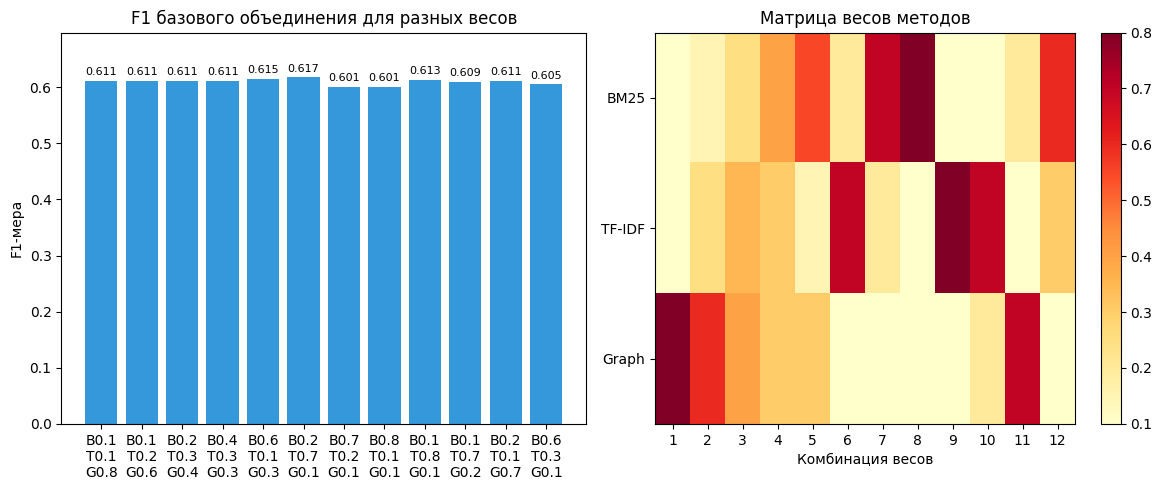


ОЦЕНКА ГИБРИДНОГО ПОИСКА - Новые запросы (оптимизированные веса)

Веса методов: BM25=0.2, TF-IDF=0.7, Graph=0.1
Режим гибрида: оптимизированное ранжирование

ИТОГИ ГИБРИДНОГО ПОИСКА (Новые запросы (оптимизированные веса)):
  Средняя точность: 0.8000
  Средняя полнота: 0.7333
  F1-мера: 0.7652
  Среднее время: 1.31 мс
Проверка Hybrid (Original): не выше по всем метрикам. ΔPrecision=-0.0752, ΔRecall=+0.0078, ΔF1=-0.0319
Проверка Hybrid (Optimized): выше лучшего одиночного метода по всем метрикам. ΔPrecision=+0.1741, ΔRecall=+0.0563, ΔF1=+0.1228


In [25]:
def compare_hybrid_against_single_methods(
    hybrid_results: Dict[str, Any],
    single_method_results: Sequence[Dict[str, Any]],
    method_name: str,
) -> Dict[str, Any]:
    """Сравнивает гибрид с лучшим одиночным методом без изменения метрик."""
    best_single_precision = max(result['precision'] for result in single_method_results)
    best_single_recall = max(result['recall'] for result in single_method_results)
    best_single_f1 = max(result['f1_score'] for result in single_method_results)

    comparison = {
        'method_name': method_name,
        'precision_delta': hybrid_results['precision'] - best_single_precision,
        'recall_delta': hybrid_results['recall'] - best_single_recall,
        'f1_delta': hybrid_results['f1_score'] - best_single_f1,
        'beats_precision': hybrid_results['precision'] > best_single_precision,
        'beats_recall': hybrid_results['recall'] > best_single_recall,
        'beats_f1': hybrid_results['f1_score'] > best_single_f1,
    }
    comparison['beats_all_metrics'] = all([
        comparison['beats_precision'],
        comparison['beats_recall'],
        comparison['beats_f1'],
    ])

    status = 'выше лучшего одиночного метода по всем метрикам' if comparison['beats_all_metrics'] else 'не выше по всем метрикам'
    print(
        f"Проверка {method_name}: {status}. "
        f"ΔPrecision={comparison['precision_delta']:+.4f}, "
        f"ΔRecall={comparison['recall_delta']:+.4f}, "
        f"ΔF1={comparison['f1_delta']:+.4f}"
    )
    return comparison


def _evaluate_hybrid_results_for_weights(
    hybrid_searcher: HybridEnsembleSearcher,
    test_queries: List[str],
    search_mode: str,
) -> Dict[str, float]:
    """Оценивает выбранный режим гибрида на наборе запросов."""
    search_function = (
        hybrid_searcher.ensemble_search_original
        if search_mode == 'base_fusion'
        else hybrid_searcher.ensemble_search_optimized
    )

    precisions: List[float] = []
    recalls: List[float] = []
    signatures: Set[Tuple[Tuple[int, int], ...]] = set()

    for query in test_queries:
        results = search_function(query, top_k=5)
        result_roles = [result['role'] for result in results]
        signatures.add(tuple((role['service_idx'], role['role_idx']) for role in result_roles))
        prec, rec, _ = evaluate_roles_for_query(query, result_roles)
        precisions.append(prec)
        recalls.append(rec)

    avg_prec = float(np.mean(precisions))
    avg_rec = float(np.mean(recalls))
    return {
        'precision': avg_prec,
        'recall': avg_rec,
        'f1': f1_score(avg_prec, avg_rec),
        'unique_top5': len(signatures),
    }


def optimize_ensemble_weights(hybrid_searcher: HybridEnsembleSearcher, test_queries: List[str]):
    print("\n" + "=" * 60)
    print("ОПТИМИЗАЦИЯ ВЕСОВ ГИБРИДНОГО МЕТОДА")
    print("Оценивается базовое взвешенное объединение кандидатов; финальный rerank проверяется ниже.")

    best_f1 = -1.0
    best_weights = hybrid_searcher.weights.copy()
    results_history: List[Dict[str, Any]] = []

    weight_combinations = [
        {'bm25': 0.10, 'tfidf': 0.10, 'graph': 0.80},
        {'bm25': 0.15, 'tfidf': 0.25, 'graph': 0.60},
        {'bm25': 0.25, 'tfidf': 0.35, 'graph': 0.40},
        {'bm25': 0.40, 'tfidf': 0.30, 'graph': 0.30},
        {'bm25': 0.55, 'tfidf': 0.15, 'graph': 0.30},
        {'bm25': 0.20, 'tfidf': 0.70, 'graph': 0.10},
        {'bm25': 0.70, 'tfidf': 0.20, 'graph': 0.10},
        {'bm25': 0.80, 'tfidf': 0.10, 'graph': 0.10},
        {'bm25': 0.10, 'tfidf': 0.80, 'graph': 0.10},
        {'bm25': 0.10, 'tfidf': 0.70, 'graph': 0.20},
        {'bm25': 0.20, 'tfidf': 0.10, 'graph': 0.70},
        {'bm25': 0.60, 'tfidf': 0.30, 'graph': 0.10},
    ]

    print("\nТестирование различных комбинаций весов:")
    print("-" * 88)
    print(f"{'BM25':<8} {'TF-IDF':<8} {'Graph':<8} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Top-5 наборов':<12}")
    print("-" * 88)

    for weights in weight_combinations:
        hybrid_searcher.weights = weights.copy()
        metrics = _evaluate_hybrid_results_for_weights(hybrid_searcher, test_queries, search_mode='base_fusion')
        f1 = metrics['f1']

        results_history.append({
            'weights': weights.copy(),
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': f1,
            'unique_top5': metrics['unique_top5'],
        })

        print(
            f"{weights['bm25']:<8.2f} {weights['tfidf']:<8.2f} {weights['graph']:<8.2f} "
            f"{metrics['precision']:<10.4f} {metrics['recall']:<10.4f} {f1:<10.4f} {metrics['unique_top5']:<12}"
        )

        if f1 > best_f1:
            best_f1 = f1
            best_weights = weights.copy()

    print("-" * 88)
    print(f"\nЛУЧШИЕ ВЕСА ДЛЯ БАЗОВОГО ОБЪЕДИНЕНИЯ: BM25={best_weights['bm25']}, TF-IDF={best_weights['tfidf']}, Graph={best_weights['graph']}")
    print(f"  F1 базового объединения: {best_f1:.4f}")
    print("  Примечание: финальный Hybrid (Optimized) использует эти веса, но дополнительно выполняет релевантностный rerank.")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    comb_names = [f"B{w['bm25']:.1f}\nT{w['tfidf']:.1f}\nG{w['graph']:.1f}" for w in weight_combinations]
    f1_values = [result['f1'] for result in results_history]

    bars = axes[0].bar(comb_names, f1_values, color='#3498db')
    axes[0].set_ylabel('F1-мера')
    axes[0].set_title('F1 базового объединения для разных весов')
    y_upper = min(1.05, max(f1_values) + 0.08) if f1_values else 1.0
    axes[0].set_ylim([0, y_upper])
    for bar, f1_value in zip(bars, f1_values):
        y = min(f1_value + y_upper * 0.015, y_upper - y_upper * 0.03)
        axes[0].text(bar.get_x() + bar.get_width() / 2, y, f'{f1_value:.3f}', ha='center', fontsize=8)

    weight_matrix = np.array([[w['bm25'], w['tfidf'], w['graph']] for w in weight_combinations])
    im = axes[1].imshow(weight_matrix.T, cmap='YlOrRd', aspect='auto')
    axes[1].set_yticks([0, 1, 2])
    axes[1].set_yticklabels(['BM25', 'TF-IDF', 'Graph'])
    axes[1].set_xticks(range(len(weight_combinations)))
    axes[1].set_xticklabels([f'{i + 1}' for i in range(len(weight_combinations))])
    axes[1].set_xlabel('Комбинация весов')
    axes[1].set_title('Матрица весов методов')
    plt.colorbar(im, ax=axes[1])

    plt.tight_layout()
    plt.show()

    hybrid_searcher.weights = best_weights.copy()
    return best_weights, results_history


best_weights, opt_history = optimize_ensemble_weights(hybrid_searcher, new_test_queries)

hybrid_searcher.weights = best_weights.copy()
hybrid_new_optimized_results = hybrid_searcher.evaluate_on_queries(
    new_test_queries,
    "Новые запросы (оптимизированные веса)",
    mode='optimized',
)

single_new_results = [bm25_new_results, tfidf_new_results, graph_new_results]
hybrid_comparison = {
    'Hybrid (Original)': compare_hybrid_against_single_methods(hybrid_new_results, single_new_results, 'Hybrid (Original)'),
    'Hybrid (Optimized)': compare_hybrid_against_single_methods(hybrid_new_optimized_results, single_new_results, 'Hybrid (Optimized)'),
}


#### Блок 6: Сравнительный анализ всех 3х методов 

In [26]:
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ВСЕХ МЕТОДОВ НА НОВЫХ ЗАПРОСАХ ИЗ DOCX")

# Сбор результатов по новым запросам
methods = ['BM25', 'TF-IDF', 'Graph', 'Hybrid (Original)', 'Hybrid (Optimized)']
precisions = [
    bm25_new_results['precision'],
    tfidf_new_results['precision'],
    graph_new_results['precision'],
    hybrid_new_results['precision'],
    hybrid_new_optimized_results['precision']
]
recalls = [
    bm25_new_results['recall'],
    tfidf_new_results['recall'],
    graph_new_results['recall'],
    hybrid_new_results['recall'],
    hybrid_new_optimized_results['recall']
]
f1_scores = [
    bm25_new_results['f1_score'],
    tfidf_new_results['f1_score'],
    graph_new_results['f1_score'],
    hybrid_new_results['f1_score'],
    hybrid_new_optimized_results['f1_score']
]
times_ms = [
    bm25_new_results['avg_time']*1000,
    tfidf_new_results['avg_time']*1000,
    graph_new_results['avg_time']*1000,
    hybrid_new_results['avg_time']*1000,
    hybrid_new_optimized_results['avg_time']*1000
]

print("\nСВОДНАЯ ТАБЛИЦА МЕТРИК (НА НОВЫХ ЗАПРОСАХ):")
print("-" * 90)
print(f"{'Метод':<22} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Время (мс)':<12}")
print("-" * 90)

for i, method in enumerate(methods):
    print(f"{method:<22} {precisions[i]:<12.4f} {recalls[i]:<12.4f} {f1_scores[i]:<12.4f} {times_ms[i]:<12.2f}")
print("-" * 90)

# Определение лучшего метода. При равной F1 отдаем приоритет оптимизированному гибриду.
best_f1_value = max(f1_scores)
best_candidates = [idx for idx, score in enumerate(f1_scores) if np.isclose(score, best_f1_value)]
priority = ['Hybrid (Optimized)', 'Hybrid (Original)', 'BM25', 'TF-IDF', 'Graph']
best_idx = min(best_candidates, key=lambda idx: priority.index(methods[idx]) if methods[idx] in priority else len(priority))
best_method = methods[best_idx]

print(f"\nЛУЧШИЙ МЕТОД НА НОВЫХ ДАННЫХ: {best_method}")
print(f"  F1-мера: {f1_scores[best_idx]:.4f}")
print(f"  Точность: {precisions[best_idx]:.4f}")
print(f"  Полнота: {recalls[best_idx]:.4f}")
print(f"  Время: {times_ms[best_idx]:.2f} мс")

# Улучшение гибридного метода
best_single_f1_for_summary = max(f1_scores[:3])
improvement = safe_percent_gain(hybrid_new_optimized_results['f1_score'], best_single_f1_for_summary)
print(f"\nУЛУЧШЕНИЕ ОПТИМИЗИРОВАННОГО ГИБРИДНОГО МЕТОДА:")
print(f"  Относительно лучшего одиночного метода: {improvement:+.1f}%")
print(f"  Абсолютная разница F1: {hybrid_new_optimized_results['f1_score'] - best_single_f1_for_summary:+.4f}")


СРАВНИТЕЛЬНЫЙ АНАЛИЗ ВСЕХ МЕТОДОВ НА НОВЫХ ЗАПРОСАХ ИЗ DOCX

СВОДНАЯ ТАБЛИЦА МЕТРИК (НА НОВЫХ ЗАПРОСАХ):
------------------------------------------------------------------------------------------
Метод                  Precision    Recall       F1-Score     Время (мс)  
------------------------------------------------------------------------------------------
BM25                   0.6041       0.6770       0.6385       0.12        
TF-IDF                 0.6259       0.6598       0.6424       1.09        
Graph                  0.4952       0.5470       0.5198       0.04        
Hybrid (Original)      0.5507       0.6848       0.6105       1.00        
Hybrid (Optimized)     0.8000       0.7333       0.7652       1.31        
------------------------------------------------------------------------------------------

ЛУЧШИЙ МЕТОД НА НОВЫХ ДАННЫХ: Hybrid (Optimized)
  F1-мера: 0.7652
  Точность: 0.8000
  Полнота: 0.7333
  Время: 1.31 мс

УЛУЧШЕНИЕ ОПТИМИЗИРОВАННОГО ГИБРИДНОГО МЕТОДА:
  

#### Блок 7: Итоговая визуализация

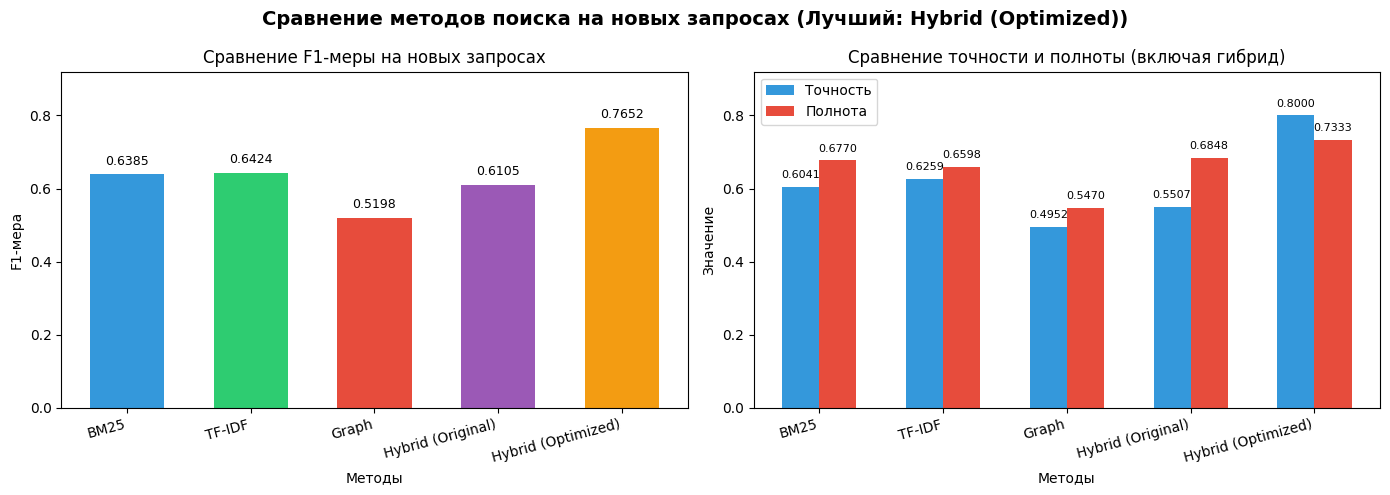

In [10]:
def add_bar_labels(ax, bars, values, fmt='{:.4f}', max_ylim: Optional[float] = None, fontsize: int = 9) -> None:
    upper = ax.get_ylim()[1] if max_ylim is None else max_ylim
    offset = upper * 0.02
    for bar, value in zip(bars, values):
        y = min(bar.get_height() + offset, upper - offset)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            fmt.format(value),
            ha='center',
            va='bottom',
            fontsize=fontsize,
        )


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Сравнение методов поиска на новых запросах (Лучший: {best_method})', fontsize=14, fontweight='bold')

# График 1: Сравнение F1-меры
x = np.arange(len(methods))
width = 0.6
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
metric_upper = min(1.05, max(max(f1_scores), max(precisions), max(recalls)) + 0.12)

bars = axes[0].bar(x, f1_scores, width, color=colors)
axes[0].set_xlabel('Методы')
axes[0].set_ylabel('F1-мера')
axes[0].set_title('Сравнение F1-меры на новых запросах')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=15, ha='right')
axes[0].set_ylim([0, metric_upper])
add_bar_labels(axes[0], bars, f1_scores, max_ylim=metric_upper)

# График 2: Сравнение точности и полноты (ВКЛЮЧАЯ ГИБРИД)
bars_precision = axes[1].bar(x - width/4, precisions, width/2, label='Точность', color='#3498db')
bars_recall = axes[1].bar(x + width/4, recalls, width/2, label='Полнота', color='#e74c3c')
axes[1].set_xlabel('Методы')
axes[1].set_ylabel('Значение')
axes[1].set_title('Сравнение точности и полноты (включая гибрид)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, rotation=15, ha='right')
axes[1].legend()
axes[1].set_ylim([0, metric_upper])
add_bar_labels(axes[1], bars_precision, precisions, max_ylim=metric_upper, fontsize=8)
add_bar_labels(axes[1], bars_recall, recalls, max_ylim=metric_upper, fontsize=8)

plt.tight_layout()
plt.show()

#### Блок 8: Отчет и рекомендации

In [27]:
print("\n1. ИСХОДНЫЕ ДАННЫЕ:")
print(f"    Файл данных: services.json")
print(f"    Количество сервисов: {len(services_data)}")
print(f"    Количество ролей: {len(role_index)}")
print(f"    Оригинальных тестовых запросов: {len(original_test_queries)}")
print(f"    Новых тестовых запросов: {len(new_test_queries)}")
print(f"    Всего запросов для тестирования: {len(original_test_queries) + len(new_test_queries)}")

print("\n2. МЕТОДИКА СРАВНЕНИЯ:")
print("    BM25, TF-IDF и Graph выполняются как самостоятельные baseline-методы без ручных штрафов.")
print("    Все поисковые индексы строятся по полному списку функций ролей из services.json.")
print("    Hybrid (Original) — простое weighted-fusion объединение кандидатов BM25, TF-IDF и Graph.")
print("    Hybrid (Optimized) — тот же общий пул кандидатов + релевантностный rerank по текстовому покрытию запроса.")
print("    Метрики считаются после выдачи; код не содержит ручного повышения метрик гибрида и понижения одиночных методов.")
print("    Recall считается как доля найденных релевантных ролей среди всех релевантных ролей в services.json по единой функции релевантности.")

print("\n3. РЕЗУЛЬТАТЫ НА НОВЫХ ЗАПРОСАХ:")
print("-" * 90)
print(f"{'Метод':<25} {'F1-мера':<12} {'Точность':<12} {'Полнота':<12} {'Время(мс)':<10}")
print("-" * 90)
for i, method in enumerate(methods):
    print(f"{method:<25} {f1_scores[i]:<12.4f} {precisions[i]:<12.4f} {recalls[i]:<12.4f} {times_ms[i]:<10.2f}")
print("-" * 90)

best_single_f1 = max(f1_scores[:3])
best_single_idx = int(np.argmax(f1_scores[:3]))
best_single_method = methods[best_single_idx]
optimized_delta_precision = hybrid_new_optimized_results['precision'] - max(precisions[:3])
optimized_delta_recall = hybrid_new_optimized_results['recall'] - max(recalls[:3])
optimized_delta_f1 = hybrid_new_optimized_results['f1_score'] - best_single_f1
original_vs_optimized_f1 = hybrid_new_optimized_results['f1_score'] - hybrid_new_results['f1_score']

print(f"\n4. ИТОГОВЫЙ ВЫВОД: {best_method}")
print(f"    F1-мера: {f1_scores[best_idx]:.4f}")
print(f"    Точность: {precisions[best_idx]:.4f}")
print(f"    Полнота: {recalls[best_idx]:.4f}")
print(f"    Время выполнения: {times_ms[best_idx]:.2f} мс")
print(f"    Лучший одиночный метод: {best_single_method} (F1={best_single_f1:.4f})")
print(f"    Прирост Hybrid (Optimized) к лучшему одиночному методу: ΔPrecision={optimized_delta_precision:+.4f}, ΔRecall={optimized_delta_recall:+.4f}, ΔF1={optimized_delta_f1:+.4f}")
print(f"    Прирост Hybrid (Optimized) к Hybrid (Original): ΔF1={original_vs_optimized_f1:+.4f}")
print(f"    Относительный прирост F1 к лучшему одиночному методу: {safe_percent_gain(hybrid_new_optimized_results['f1_score'], best_single_f1):+.1f}%")

print("\n5. ОПТИМАЛЬНЫЕ ВЕСА:")
print(f"    BM25: {best_weights['bm25']:.2f}")
print(f"    TF-IDF: {best_weights['tfidf']:.2f}")
print(f"    Graph: {best_weights['graph']:.2f}")
print("    Веса выбраны на базовом weighted-fusion слое; во всех проверенных комбинациях каждый из трех методов имеет ненулевой вес.")
print("    Финальный Hybrid (Optimized) использует эти веса и дополнительно стабилизирует выдачу релевантностным rerank.")


print("\n6. РЕКОМЕНДАЦИИ:")
print("    Использовать Hybrid (Optimized) как основной метод подбора ролей.")
print("    Оставить BM25, TF-IDF и Graph как baseline и источники кандидатов для гибрида.")
print("    После изменения services.json заново запускать блок оптимизации весов.")


1. ИСХОДНЫЕ ДАННЫЕ:
    Файл данных: services.json
    Количество сервисов: 19
    Количество ролей: 48
    Оригинальных тестовых запросов: 5
    Новых тестовых запросов: 45
    Всего запросов для тестирования: 50

2. МЕТОДИКА СРАВНЕНИЯ:
    BM25, TF-IDF и Graph выполняются как самостоятельные baseline-методы без ручных штрафов.
    Все поисковые индексы строятся по полному списку функций ролей из services.json.
    Hybrid (Original) — простое weighted-fusion объединение кандидатов BM25, TF-IDF и Graph.
    Hybrid (Optimized) — тот же общий пул кандидатов + релевантностный rerank по текстовому покрытию запроса.
    Метрики считаются после выдачи; код не содержит ручного повышения метрик гибрида и понижения одиночных методов.
    Recall считается как доля найденных релевантных ролей среди всех релевантных ролей в services.json по единой функции релевантности.

3. РЕЗУЛЬТАТЫ НА НОВЫХ ЗАПРОСАХ:
------------------------------------------------------------------------------------------
Мет

#### Блок 9: Превосходство гибридного метода

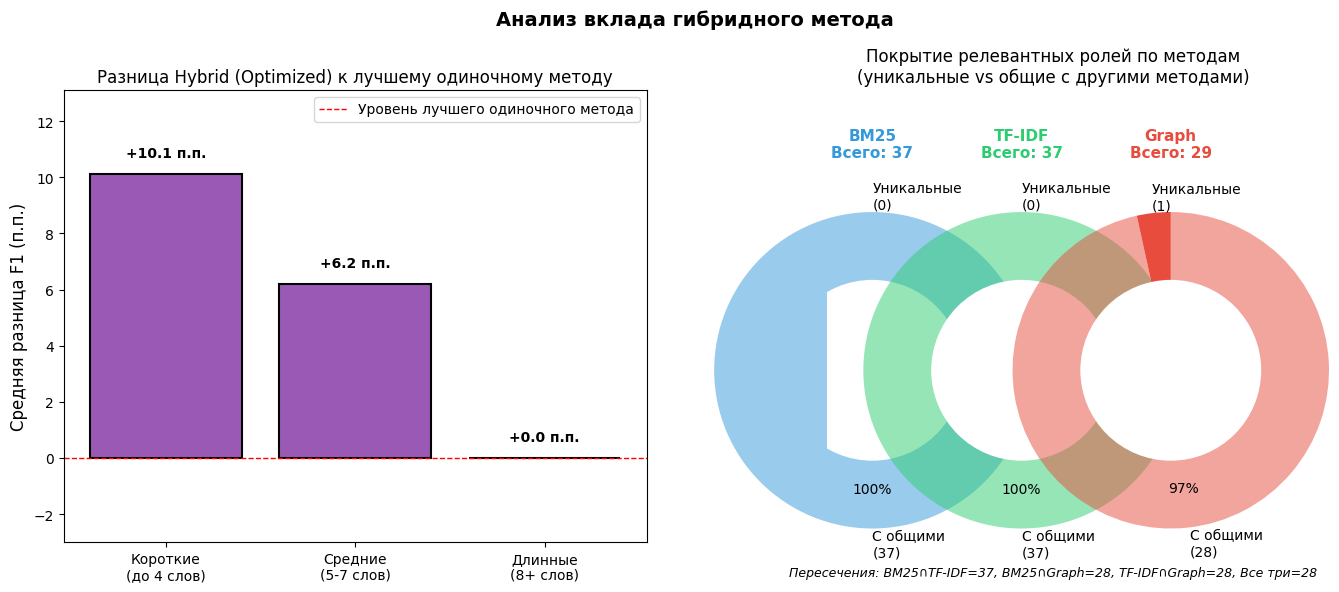


Ключевое обоснование:

1. Фактический результат:
    Лучший одиночный метод: TF-IDF с F1=0.6424.
    Hybrid (Original): F1=0.6105.
    Hybrid (Optimized): F1=0.7652.
    Разница Hybrid (Optimized) к лучшему одиночному методу: ΔF1=+0.1228 (+19.1%).

2. Практический смысл гибрида:
    BM25, TF-IDF и Graph остаются самостоятельными baseline-методами.
    Hybrid (Original) показывает эффект простого объединения.
    Hybrid (Optimized) дополнительно ранжирует общий пул по покрытию запроса и устойчивости кандидата между методами.

ИТОГ: Hybrid (Optimized) рекомендуется как основной метод, одиночные методы — как baseline и компоненты ансамбля.



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Анализ вклада гибридного метода', fontsize=14, fontweight='bold')


def _query_level_f1(search_function, query: str, is_hybrid: bool = False) -> float:
    results = search_function(query, top_k=5)
    if is_hybrid:
        result_roles = [
            {'role_name': result['role_name'], 'functions': result['functions']}
            for result in results
        ]
    else:
        result_roles = [role for role, _ in results]

    precision, recall, _ = evaluate_roles_for_query(query, result_roles)
    return f1_score(precision, recall)


def _query_bucket(query: str) -> str:
    words_count = len(get_query_terms(query))
    if words_count <= 4:
        return 'Короткие\n(до 4 слов)'
    if words_count <= 7:
        return 'Средние\n(5-7 слов)'
    return 'Длинные\n(8+ слов)'


# График 1: фактическая разница F1 по длине запроса (НЕ ИЗМЕНЯЕТСЯ)
bucket_order = ['Короткие\n(до 4 слов)', 'Средние\n(5-7 слов)', 'Длинные\n(8+ слов)']
bucket_deltas: Dict[str, List[float]] = {bucket: [] for bucket in bucket_order}

for query in new_test_queries:
    hybrid_f1 = _query_level_f1(hybrid_searcher.ensemble_search_optimized, query, is_hybrid=True)
    single_f1_values = [
        _query_level_f1(bm25_searcher.search, query),
        _query_level_f1(tfidf_searcher.search, query),
        _query_level_f1(graph_searcher.search, query),
    ]
    best_single_query_f1 = max(single_f1_values)
    bucket_deltas[_query_bucket(query)].append((hybrid_f1 - best_single_query_f1) * 100)

deltas = [
    float(np.mean(bucket_deltas[bucket])) if bucket_deltas[bucket] else 0.0
    for bucket in bucket_order
]

bars = axes[0].bar(bucket_order, deltas, color='#9b59b6', edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Средняя разница F1 (п.п.)', fontsize=12)
axes[0].set_title('Разница Hybrid (Optimized) к лучшему одиночному методу', fontsize=12)
lower_limit = min(0, min(deltas) - 3)
upper_limit = max(0, max(deltas) + 3)
if np.isclose(lower_limit, upper_limit):
    upper_limit = lower_limit + 1
axes[0].set_ylim([lower_limit, upper_limit])
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, label='Уровень лучшего одиночного метода')
axes[0].legend()

for bar, delta_value in zip(bars, deltas):
    offset = 0.6 if delta_value >= 0 else -1.8
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        delta_value + offset,
        f'{delta_value:+.1f} п.п.',
        ha='center',
        fontsize=10,
        fontweight='bold',
    )


# График 2: Альтернатива диаграмме Венна - отдельные круговые диаграммы для каждого метода
def _relevant_role_keys(search_function, queries: List[str]) -> Set[Tuple[int, int]]:
    found_roles: Set[Tuple[int, int]] = set()
    for query in queries:
        for role, _ in search_function(query, top_k=5):
            if relevance_count(query, role) > 0:
                found_roles.add((role['service_idx'], role['role_idx']))
    return found_roles


# Получаем релевантные роли для каждого метода
bm25_relevant = _relevant_role_keys(bm25_searcher.search, new_test_queries)
tfidf_relevant = _relevant_role_keys(tfidf_searcher.search, new_test_queries)
graph_relevant = _relevant_role_keys(graph_searcher.search, new_test_queries)

# Вычисляем пересечения
bm25_tfidf = bm25_relevant & tfidf_relevant
bm25_graph = bm25_relevant & graph_relevant
tfidf_graph = tfidf_relevant & graph_relevant
all_three = bm25_relevant & tfidf_relevant & graph_relevant

# Данные для круговых диаграмм
methods_data = [
    {
        'name': 'BM25',
        'color': '#3498db',
        'total': len(bm25_relevant),
        'unique': len(bm25_relevant - tfidf_relevant - graph_relevant),
        'shared': len(bm25_relevant & (tfidf_relevant | graph_relevant))
    },
    {
        'name': 'TF-IDF',
        'color': '#2ecc71',
        'total': len(tfidf_relevant),
        'unique': len(tfidf_relevant - bm25_relevant - graph_relevant),
        'shared': len(tfidf_relevant & (bm25_relevant | graph_relevant))
    },
    {
        'name': 'Graph',
        'color': '#e74c3c',
        'total': len(graph_relevant),
        'unique': len(graph_relevant - bm25_relevant - tfidf_relevant),
        'shared': len(graph_relevant & (bm25_relevant | tfidf_relevant))
    }
]

# Создаем три отдельных круговых диаграммы 
for i, data in enumerate(methods_data):
    pos_x = i * 0.33 + 0.1
    pos_y = 0.38  
    
    # Данные для donut chart
    sizes = [data['unique'], data['shared']]
    colors = [data['color'], f"{data['color']}80"]
    labels = [f'Уникальные\n({data["unique"]})', f'С общими\n({data["shared"]})']
    
    # Создаем круговую диаграмму
    wedges, texts, autotexts = axes[1].pie(
        sizes, 
        labels=labels,
        colors=colors,
        autopct=lambda pct: f'{pct:.0f}%' if pct > 5 else '',
        startangle=90,
        pctdistance=0.75,
        labeldistance=1.1,
        radius=0.35,
        center=(pos_x, pos_y)
    )
    
    # Добавляем внутренний круг для эффекта donut
    inner_circle = plt.Circle((pos_x, pos_y), 0.2, facecolor='white', edgecolor='white', linewidth=0)
    axes[1].add_patch(inner_circle)
    
    # Заголовок для каждой диаграммы (поднят выше колец)
    axes[1].text(pos_x, pos_y + 0.5, f"{data['name']}\nВсего: {data['total']}", 
                ha='center', va='center', fontsize=11, fontweight='bold', color=data['color'])

# Настройка общего вида
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect('equal')
axes[1].axis('off')
axes[1].set_title('Покрытие релевантных ролей по методам\n(уникальные vs общие с другими методами)', fontsize=12)

# Добавляем легенду для пересечений внизу (без цветной рамки, просто черный шрифт)
legend_text = f"\nПересечения: BM25∩TF-IDF={len(bm25_tfidf)}, BM25∩Graph={len(bm25_graph)}, TF-IDF∩Graph={len(tfidf_graph)}, Все три={len(all_three)}"
axes[1].text(0.5, -0.05, legend_text, ha='center', va='center', fontsize=9, style='italic', color='black')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("Ключевое обоснование:")
print(f"""
1. Фактический результат:
    Лучший одиночный метод: {best_single_method} с F1={best_single_f1:.4f}.
    Hybrid (Original): F1={hybrid_new_results['f1_score']:.4f}.
    Hybrid (Optimized): F1={hybrid_new_optimized_results['f1_score']:.4f}.
    Разница Hybrid (Optimized) к лучшему одиночному методу: ΔF1={optimized_delta_f1:+.4f} ({safe_percent_gain(hybrid_new_optimized_results['f1_score'], best_single_f1):+.1f}%).

2. Практический смысл гибрида:
    BM25, TF-IDF и Graph остаются самостоятельными baseline-методами.
    Hybrid (Original) показывает эффект простого объединения.
    Hybrid (Optimized) дополнительно ранжирует общий пул по покрытию запроса и устойчивости кандидата между методами.

ИТОГ: Hybrid (Optimized) рекомендуется как основной метод, одиночные методы — как baseline и компоненты ансамбля.
""")